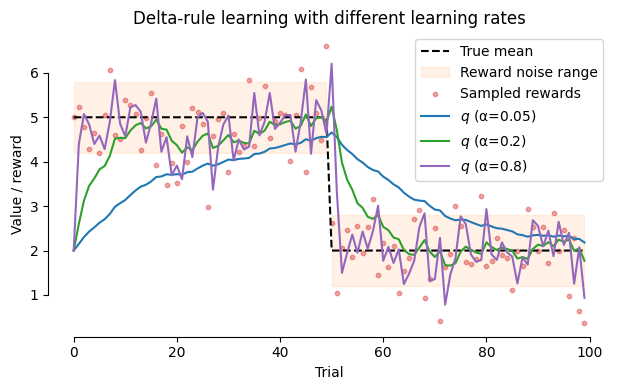

'figs/delta_rule_learning_rates.png'

In [17]:
# Simulation and plot for delta-rule learning with different learning rates
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----- Parameters -----
T = 100                 # total trials
change_pt = 50          # change point
mu1, mu2 = 5.0, 2.0     # true means before/after change
sigma = 0.8             # reward noise (std)
alphas = [0.05, 0.2, 0.8]   # low, medium, high learning rates

# ----- Generate rewards -----
true_mean = np.concatenate([np.full(change_pt, mu1), np.full(T - change_pt, mu2)])
rng = np.random.default_rng(7)
rewards = rng.normal(true_mean, sigma)

# ----- Delta-rule learning for each alpha -----
q_values = {}
for alpha in alphas:
    q = np.zeros(T)
    q[0] = 2.0
    for t in range(1, T):
        q[t] = q[t-1] + alpha * (rewards[t-1] - q[t-1])
    q_values[alpha] = q

x = np.arange(T)

# ----- Plot -----
plt.figure(figsize=(6.3, 4))  # width matches A4 textwidth, adjust height as needed

# True mean and reward distribution
plt.plot(x, true_mean, linestyle="--", color="black", label="True mean")
plt.fill_between(np.arange(0, change_pt), mu1 - sigma, mu1 + sigma, alpha=0.1, color="tab:orange", label="Reward noise range")
plt.fill_between(np.arange(change_pt, T), mu2 - sigma, mu2 + sigma, alpha=0.1, color="tab:orange")
plt.scatter(x, rewards, s=10, alpha=0.4, color="tab:red", label="Sampled rewards")

# Learning curves
colors = ["tab:blue", "tab:green", "tab:purple"]
for alpha, q in q_values.items():
    plt.plot(x, q, label=f"$q$ (α={alpha})", color=colors[alphas.index(alpha)])


# Change point
plt.xlabel("Trial")
plt.ylabel("Value / reward")
plt.title("Delta-rule learning with different learning rates")
plt.legend(loc="best")
plt.tight_layout()

# despine
sns.despine(trim=True)

out_path = "figs/delta_rule_learning_rates.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

out_path
